In [ ]:
# --- project bootstrap ---
import os
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
os.chdir(ROOT)
# -------------------------


In [1]:
import os
import multiprocessing as mp

cpu_cap = 45
cpu_count = mp.cpu_count()
cpu_use = min(cpu_cap, cpu_count)
os.environ["MY_CPU_COUNT"] = str(cpu_use)
os.environ["OMP_NUM_THREADS"] = str(cpu_use)
os.environ["OPENBLAS_NUM_THREADS"] = str(cpu_use)
os.environ["MKL_NUM_THREADS"] = str(cpu_use)
os.environ["NUMEXPR_MAX_THREADS"] = str(cpu_use)
try:
    os.sched_setaffinity(0, set(range(cpu_use)))
except Exception as exc:
    print(f"CPU affinity not set: {exc}")


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
import fgtn.classA_U1FGTN as classA_U1FGTN
importlib.reload(classA_U1FGTN)
from fgtn.classA_U1FGTN import classA_U1FGTN

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
import fgtn.classA_U1FGTN as classA_U1FGTN
import importlib
importlib.reload(classA_U1FGTN)
from fgtn.classA_U1FGTN import classA_U1FGTN
# Lattice + DW parameters and circuit depth
Nx, Ny   = 12, 12
alpha_1, alpha_2 = 30, 1
cycles   = 60  # adjust as needed

def product_state_one_per_cell_top_layer(Nx, Ny):
    """
    Full-layer covariance with one occupied top-layer mode per unit cell.
    Indexing matches i = μ + 2*x + 2*Nx*y for the top layer, and the bottom
    layer is offset by 2*Nx*Ny.
    """
    Nlayer = 2 * Nx * Ny
    G = -np.eye(Nlayer, dtype=np.complex128)  # start all empty (-1)

    # Occupy the μ=2 top-layer mode in each cell: set diag to +1
    for y in range(Ny):
        for x in range(Nx):
            idx_top_mu0 = 1 + 2 * x + 2 * Nx * y
            G[idx_top_mu0, idx_top_mu0] = 1.0

    return G

G_init = product_state_one_per_cell_top_layer(Nx, Ny)

# Build model and run adaptive circuit; keep history in memory, avoid cache saves
model = classA_U1FGTN(Nx, Ny, nshell=2, DW=True, alpha_1=alpha_1, alpha_2=alpha_2)
res = model.run_markov_circuit(
    G_history=True,
    cycles=cycles,
    progress=True,
    G_init=G_init,
    save=True,                # do not save history to disk
    samples=1,
    p_meas=1,
    parallelize_samples=False,
    sequence="dw_symmetric",
    top_triv_back_forth=True,
    top_triv_block_cycles=15,
    track_dw_ch=True,
)


DWs at x=(4, 8)
------------------------- classA_U1FGTN Initialized -------------------------
[info] Markov circuit will save history to cache/G_history_samples/N12x12_C60_S1_nsh2_DW1_init-default_n_a0.5_seq-dw_symmetric_exclNone_pm1.00_tbtf1_tbtflm0_tbtfbc15_markov_circuit.npz


Sample 1 | Markov RAC (top->triv 15-cycle blocks):   0%|          | 0/4320 [00:00<?, ?site/s]

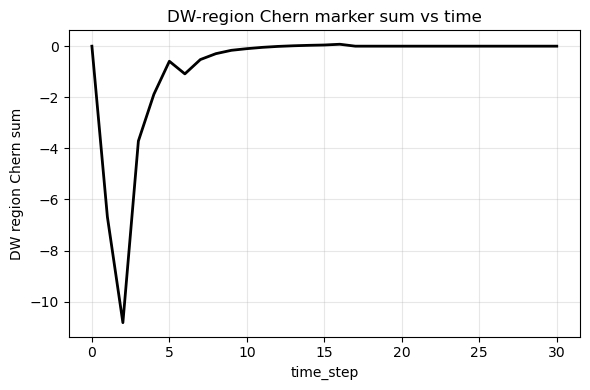

In [ ]:
dw_ch_hist = res["dw_ch_hist"]  # shape (samples, T)
t = np.arange(dw_ch_hist.shape[1])

plt.figure(figsize=(6, 4))
for s in range(dw_ch_hist.shape[0]):
    plt.plot(t, np.abs(dw_ch_hist[s]), color="0.7", lw=1.0, alpha=0.6)
plt.xlabel("time_step")
plt.ylabel("DW region Chern sum")
plt.title("DW-region Chern marker sum vs time")
plt.grid(alpha=0.3)
plt.yscale("log")
plt.tight_layout()
plt.show()

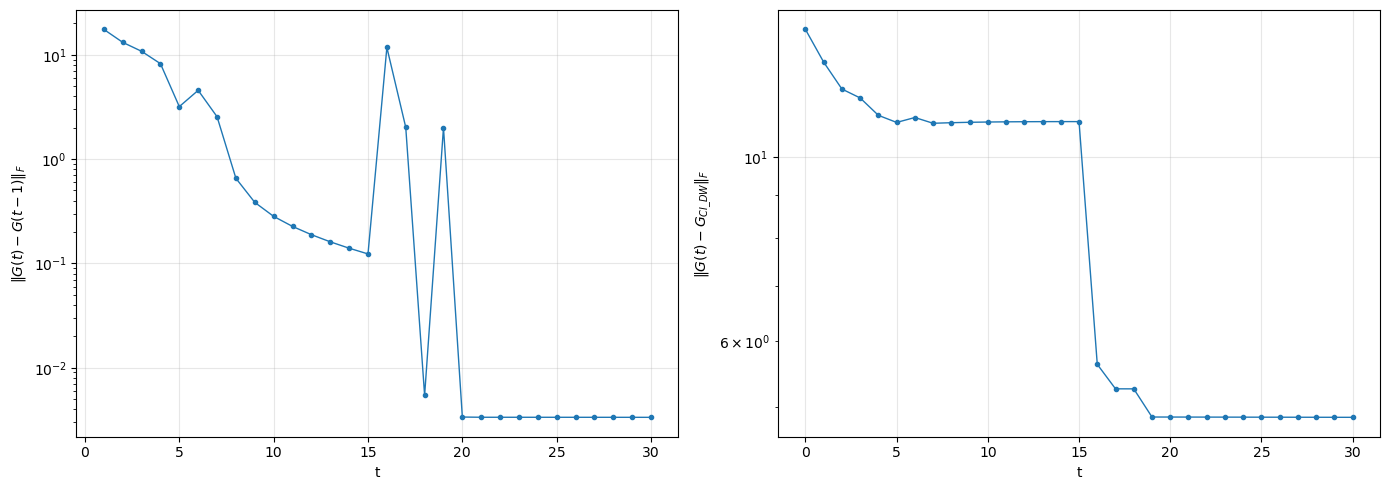

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

G_hist = res["G_hist"][0]
G_CI_DW = model.G_CI_domain_wall()

def plot_frobenius_both(G_history, G_CI_DW):
    """
    G_history: array with shape (T, N, N) or (S, T, N, N).
    G_CI_DW:   array with shape (N, N).
    Left:  ||G(t) - G(t-1)||_F
    Right: ||G(t) - G_CI_DW||_F
    """
    G = np.asarray(G_history)
    if G.ndim == 4:  # (S, T, N, N) -> average over samples
        G = G.mean(axis=0)
    if G.ndim != 3:
        raise ValueError("G_history must have shape (T,N,N) or (S,T,N,N).")
    G_CI_DW = np.asarray(G_CI_DW)
    if G_CI_DW.ndim != 2:
        raise ValueError("G_CI_DW must have shape (N,N).")

    diffs_step = np.linalg.norm(G[1:] - G[:-1], ord="fro", axis=(1, 2))
    t_step = np.arange(1, len(diffs_step) + 1)

    diffs_gs = np.linalg.norm(G - G_CI_DW[None, :, :], ord="fro", axis=(1, 2))
    t_gs = np.arange(len(diffs_gs))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

    axes[0].plot(t_step, diffs_step, marker="o", ms=3, lw=1)
    axes[0].set_xlabel("t")
    axes[0].set_ylabel(r"$\|G(t)-G(t-1)\|_F$")
    axes[0].set_yscale("log")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(t_gs, diffs_gs, marker="o", ms=3, lw=1)
    axes[1].set_xlabel("t")
    axes[1].set_ylabel(r"$\|G(t)-G_{CI\_DW}\|_F$")
    axes[1].set_yscale("log")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Example:
plot_frobenius_both(G_hist, G_CI_DW)


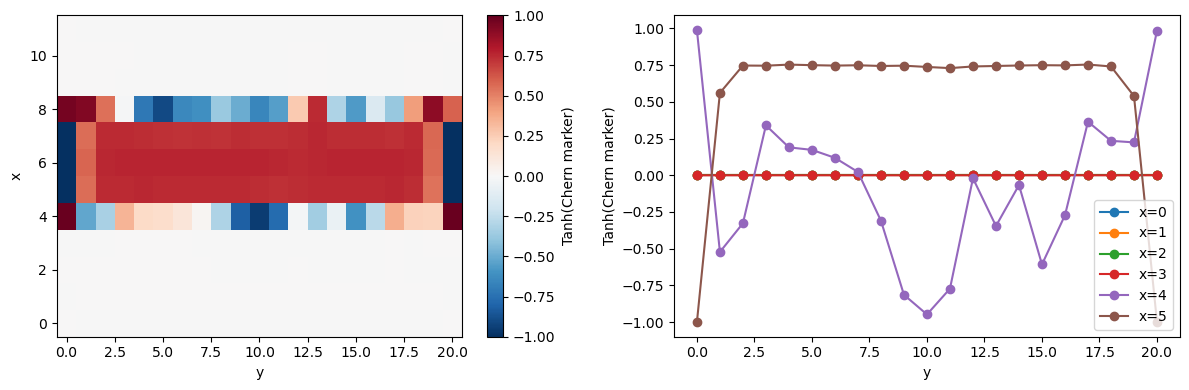

{'shape_ok': True, 'Ny': 21, 'shift_max_abs_diff': 0.43401202928617305, 'shift_pass': False, 'offdiag_ratio': 0.030419955312129262, 'offdiag_pass': False}


In [10]:
# Local Chern marker for each time step
G_ss = G_hist[-1]  # steady-state G
chmap = model.local_chern_marker_flat(G_ss)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im = axes[0].imshow(chmap, origin="lower", cmap="RdBu_r", aspect="auto", vmin=-1, vmax=1)
fig.colorbar(im, ax=axes[0], label="Tanh(Chern marker)")
axes[0].set_xlabel("y")
axes[0].set_ylabel("x")

for x in range(6):
    axes[1].plot(chmap[x, :], marker="o", label=f"x={x}")
axes[1].legend()
axes[1].set_xlabel("y")
axes[1].set_ylabel("Tanh(Chern marker)")

plt.tight_layout()
plt.show()

print(model.check_y_translation_invariance(G_ss))


In [12]:
out1 = model.sum_chern_marker_dw_region(G_ss, whole_region=True)
out2 = model.sum_chern_marker_dw_region(G_ss, whole_region=False)
out3 = model.sum_chern_marker_dw_region(G_ss, whole_region_except_bndry=True)

print(f'Chern number (DW_Region) = {out2}')
print(f'Chern number (Whole_Region) = {out1}')
print(f'Chern number (Whole_Region_Except_Boundaries) = {out3}')

Chern number (DW_Region) = 0.0005436359084285414
Chern number (Whole_Region) = 3.659552660906229e-10
Chern number (Whole_Region_Except_Boundaries) = 45.86474929865523


In [ ]:
"""
This cell runs analysis steps for the benchmarking workflow and should be read as part of a larger notebook sequence.
Review variables defined earlier in the notebook before executing.
"""
from matplotlib import colors
# --- Entanglement cut at y = Ny//2; keep upper half (use yA = np.arange(0, y_cut) for lower half) ---
y_cut = Ny // 2
yA = np.arange(y_cut, Ny)
xA = np.arange(Nx)

# Flattened indices i = μ + 2*x + 2*Nx*y for the retained region
sub_indices = []
for y in yA:
    for x in xA:
        sub_indices.append(0 + 2*x + 2*Nx*y)
        sub_indices.append(1 + 2*x + 2*Nx*y)
sub_indices = np.array(sub_indices, dtype=int)

# Reduced covariance for the subsystem
G_sub = G_ss[np.ix_(sub_indices, sub_indices)]  # shape: (2*Nx*len(yA), 2*Nx*len(yA))

# Entanglement contour on the subsystem.
# Use a helper with matching geometry (Nx, Ny_sub=len(yA)); DW flag off because we just need the contour routine.
Ny_sub = len(yA)
s_map = model.entanglement_contour(G_sub)  # shape: (Nx, Ny_sub)

# Plot: heatmap + y-cuts at fixed x with gradient colors
fig, axes = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [1, 1.2]})

# Heatmap
vmin = np.max([np.min(s_map[s_map > 0]), 1e-12])  # avoid zeros
vmax = np.max(s_map)
im2 = axes[0].imshow(
    s_map,
    origin="lower",
    cmap="magma",
    aspect="auto",
    norm=colors.LogNorm(vmin=vmin, vmax=vmax)
)
fig.colorbar(im2, ax=axes[0], label="Entanglement contour s(r)")

# y-cuts at fixed x
y_vals = np.arange(Ny_sub)
x_list = np.arange(Nx)  # change to a subset if you want fewer lines
colors = plt.cm.viridis(np.linspace(0, 1, len(x_list)))
markers = ['o','^']
for x_idx, color in zip(x_list, colors):
    if x_idx < Nx//2:
        axes[1].plot(y_vals, s_map[x_idx, :], marker=markers[0], color=color, lw=1.8, label=f"x = {x_idx}")
    else:
        axes[1].plot(y_vals, s_map[x_idx, :], marker=markers[1], color=color, lw=1.8, label=f"x = {x_idx}")
axes[1].set_xlabel("y (subsystem)")
axes[1].set_ylabel("s(x, y)")
axes[1].set_title("Cuts vs y for fixed x")
axes[1].grid(alpha=0.3, linestyle="--", linewidth=0.8)
axes[1].set_yscale('linear')

# Colorbar for x values
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=x_list.min(), vmax=x_list.max()))
sm.set_array([])
fig.colorbar(sm, ax=axes[1], label="x")

plt.tight_layout()
plt.show()


In [ ]:
"""
This cell runs analysis steps for the benchmarking workflow and should be read as part of a larger notebook sequence.
Review variables defined earlier in the notebook before executing.
"""
import numpy as np
import matplotlib.pyplot as plt
from fgtn.classA_U1FGTN import classA_U1FGTN
x_list = np.arange(Nx // 2)

def integrated_contour_for_size(model, G_gs, y_cut):
    # Tracing out (y_cut+1)*Nx sites, y_cut in [1, Ny-1])]
    yA = np.arange(y_cut, model.Ny)
    xA = np.arange(model.Nx)

    # Build flattened indices i = μ + 2*x + 2*Nx*y
    sub_indices = []
    for y in yA:
        for x in xA:
            sub_indices.append(0 + 2*x + 2*model.Nx*y)
            sub_indices.append(1 + 2*x + 2*model.Nx*y)
    sub_indices = np.array(sub_indices, dtype=int)

    # Reduced covariance
    G_sub = G_gs[np.ix_(sub_indices, sub_indices)]

    # Entanglement contour on the subsystem
    contour_helper = classA_U1FGTN(model.Nx, len(yA), DW=False, alpha_1=1, alpha_2=1)
    s_map = contour_helper.entanglement_contour(G_sub)  # shape: (Nx, Ay_size)

    # Integrated contour over y for each x
    return np.sum(s_map, axis=1)


# Sweep A_y sizes and collect curves
y_cut_list = np.arange(1, Ny)  # |A_y| from 1..Ny-1
A_y_list = Ny-y_cut_list
Sx_vs_y_cut = {x: [] for x in x_list}

for y_cut in y_cut_list:
    Sx = integrated_contour_for_size(model, G_ss, y_cut)
    for x in x_list:
        Sx_vs_y_cut[x].append(Sx[x])

# Plot: integrated contour vs |A_y| for each x
plt.figure(figsize=(7, 5))
for x in x_list:
    curve = np.array(Sx_vs_y_cut[x])
    plt.plot(A_y_list, curve, marker='o', lw=1.4, label=f"x={x}")

plt.xlabel(r"Subsystem size $|A_y|$")
plt.ylabel(r"Integrated contour $\sum_{y \in A_y} s_{A_y}(x,y)$")
plt.title("Integrated contour vs subsystem size")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.legend(ncol=3, fontsize=9)
plt.show()


In [ ]:
# choose x-range to sum over
x0 = model.DW_loc[0]
x_sum_range = np.arange(x0, x0+1)  

# Sum over x=4..5 for each cut
sum_over_x = []
for i, y_cut in enumerate(y_cut_list):
    total = 0.0
    for x in x_sum_range:
        total += Sx_vs_y_cut[x][i]
    sum_over_x.append(total)
Ay = np.array(A_y_list, dtype=float)

yvals = np.array(sum_over_x)

# log-sin x-axis for fit
xvals = np.log(np.sin(np.pi * Ay / Ny))
mask = np.isfinite(xvals)
x_fit = xvals[mask]
y_fit = yvals[mask]

# linear fit
m, b = np.polyfit(x_fit, y_fit, 1)

# R^2 and adjusted R^2
y_pred = m * x_fit + b
ss_res = np.sum((y_fit - y_pred) ** 2)
ss_tot = np.sum((y_fit - np.mean(y_fit)) ** 2)
r2 = 1 - ss_res / ss_tot
n = len(y_fit)
p = 1
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

# two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# left: plain plot vs subsystem size
axes[0].plot(Ay, yvals, marker='o', lw=1.6)
axes[0].set_xlabel(r"Subsystem size $|A_y|$")
axes[0].set_ylabel(r"$\sum_{x=3}^{5}\sum_{y\in A_y} s_{A_y}(x,y)$")
axes[0].set_title("Integrated contour vs |A_y|")
axes[0].grid(alpha=0.3)

# right: fit plot vs log(sin)
axes[1].plot(x_fit, y_fit, marker='o', lw=1.4, label="data")
axes[1].plot(x_fit, y_pred, lw=2, label=f"fit: m={m:.4f}, b={b:.4f}")
axes[1].set_xlabel(r"$\log(\sin(\pi |A_y|/N_y))$")
axes[1].set_ylabel(r"$\sum_{x=3}^{5}\sum_{y\in A_y} s_{A_y}(x,y)$")
axes[1].set_title("Fit vs log(sin)")
axes[1].grid(alpha=0.3)
axes[1].legend()

fig.tight_layout()
plt.show()

print(f"slope = {m}")
print(f"intercept = {b}")
print(f"R^2 = {r2}")
print(f"adjusted R^2 = {adj_r2}")
print(f"central charge errror = {np.abs(m-1/6)/(1/6)*100:.6g}%")


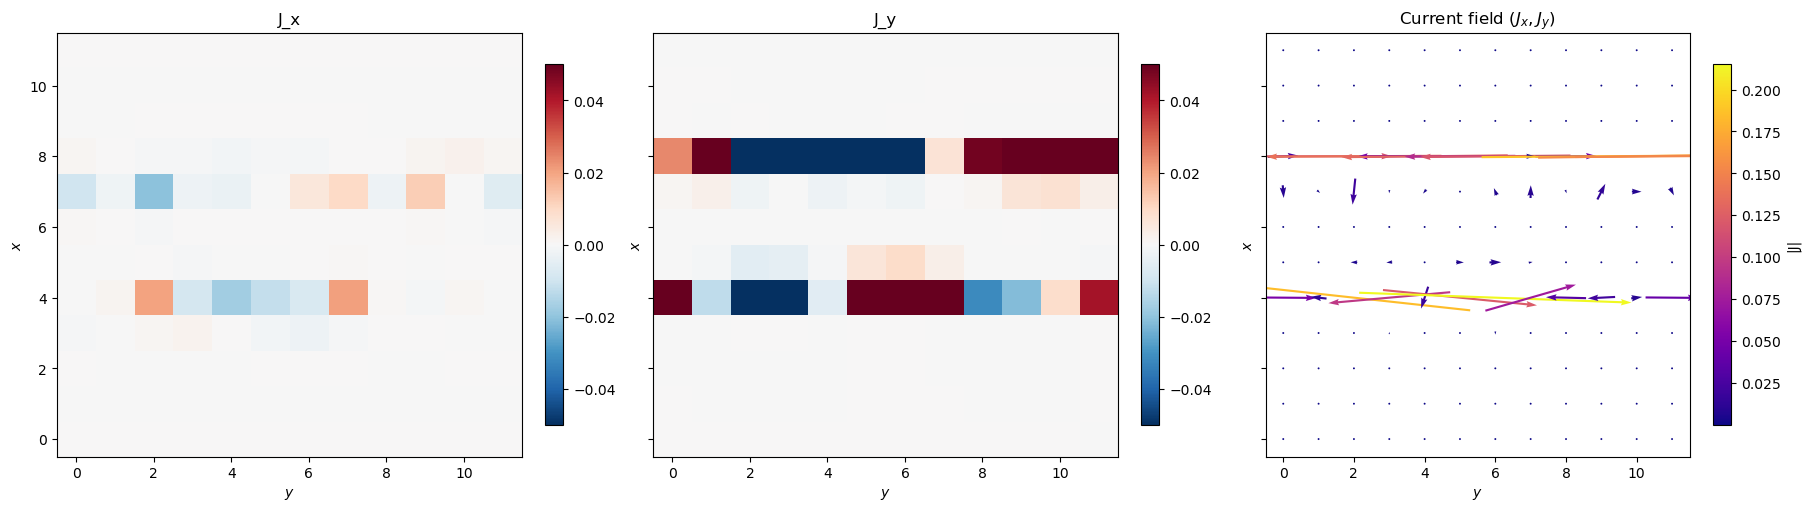

In [22]:

J_x, J_y = model.current_maps_gauge_invariant(G_ss)
fig, axes = model.plot_current_maps(J_x, J_y, figsize=(18, 5), sharey=True, vmin=-0.05, vmax=+0.05)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def compute_modular_hamiltonian(G, eps=1e-12):
    """
    Computes the Modular (Entanglement) Hamiltonian from the covariance matrix.

    Formula: H_mod = ln((1-G)/(1+G)) = -2 * arctanh(G)

    Parameters
    ----------
    G : ndarray
        Top-layer covariance matrix (2C - 1), shape (N, N), N=2*Nx*Ny.
    eps : float
        Clipping parameter to regularize eigenvalues near +/-1.

    Returns
    -------
    H_mod : ndarray
        The single-particle modular Hamiltonian matrix.
    """
    G = np.asarray(G, dtype=np.complex128)
    if G.shape[0] != G.shape[1]:
        raise ValueError("G must be square.")

    evals, evecs = np.linalg.eigh(G)
    evals = np.real_if_close(evals, tol=1e-10)
    evals = np.clip(evals, -1 + eps, 1 - eps)

    h_evals = -2.0 * np.arctanh(evals)
    H_mod = (evecs * h_evals[None, :]) @ evecs.conj().T
    return H_mod


def compute_current_density(H_mod, G, Nx, Ny):
    """
    Computes the current density generated by H_mod in state G.

    Basis assumption (top layer only):
    idx = μ + 2*x + 2*Nx*y, with μ fastest (Fortran order).

    Parameters
    ----------
    H_mod : ndarray
        Modular Hamiltonian matrix, shape (2*Nx*Ny, 2*Nx*Ny).
    G : ndarray
        Covariance matrix (2C - 1), same shape as H_mod.
    Nx, Ny : int
        Lattice dimensions.

    Returns
    -------
    Jx, Jy : ndarray (Ny, Nx)
        Current density along +x and +y bonds, arranged as [y, x].
    """
    Nx = int(Nx)
    Ny = int(Ny)
    Nlayer = 2 * Nx * Ny

    H_mod = np.asarray(H_mod, dtype=np.complex128)
    G = np.asarray(G, dtype=np.complex128)

    if H_mod.shape != (Nlayer, Nlayer) or G.shape != (Nlayer, Nlayer):
        raise ValueError(f"Expected shape ({Nlayer},{Nlayer}) for top-layer input.")

    # Correlation matrix C = (G + I) / 2
    C = 0.5 * (G + np.eye(Nlayer, dtype=np.complex128))

    # Reshape into (x, y, mu, x', y', nu) using Fortran order
    H6 = H_mod.reshape(2, Nx, Ny, 2, Nx, Ny, order="F")
    H6 = np.transpose(H6, (1, 2, 0, 4, 5, 3))  # (Nx,Ny,2,Nx,Ny,2)

    C6 = C.reshape(2, Nx, Ny, 2, Nx, Ny, order="F")
    C6 = np.transpose(C6, (1, 2, 0, 4, 5, 3))  # (Nx,Ny,2,Nx,Ny,2)

    # Neighbor indices
    x_idx = np.arange(Nx)[:, None]
    y_idx = np.arange(Ny)[None, :]
    x_next = (x_idx + 1) % Nx
    y_next = (y_idx + 1) % Ny

    # X-direction current
    Hx = H6[x_idx, y_idx, :, x_next, y_idx, :]  # (Nx,Ny,2,2)
    Cx = C6[x_next, y_idx, :, x_idx, y_idx, :]  # (Nx,Ny,2,2)
    Jx = 2.0 * np.imag(np.sum(Hx * np.swapaxes(Cx, -1, -2), axis=(2, 3)))

    # Y-direction current
    Hy = H6[x_idx, y_idx, :, x_idx, y_next, :]  # (Nx,Ny,2,2)
    Cy = C6[x_idx, y_next, :, x_idx, y_idx, :]  # (Nx,Ny,2,2)
    Jy = 2.0 * np.imag(np.sum(Hy * np.swapaxes(Cy, -1, -2), axis=(2, 3)))

    # Return as (Ny, Nx) for plotting with standard meshgrid
    return Jx.T, Jy.T


def plot_modular_current(Jx, Jy, title="Modular Current"):
    """
    Visualizes the modular current vector field.
    Expects Jx, Jy shaped (Ny, Nx).
    Plots with horizontal axis = y, vertical axis = x.
    """
    Ny, Nx = Jx.shape

    # Transpose so rows -> x, cols -> y
    Jx_plot = Jx.T
    Jy_plot = Jy.T

    fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)

    im0 = axes[0].imshow(Jx_plot, origin="lower", cmap="RdBu_r", aspect="auto")
    axes[0].set_title("Jx")
    axes[0].set_xlabel("y")
    axes[0].set_ylabel("x")
    fig.colorbar(im0, ax=axes[0], label="Jx")

    im1 = axes[1].imshow(Jy_plot, origin="lower", cmap="RdBu_r", aspect="auto")
    axes[1].set_title("Jy")
    axes[1].set_xlabel("y")
    axes[1].set_ylabel("x")
    fig.colorbar(im1, ax=axes[1], label="Jy")

    plt.show()


def plot_modular_quiver(Jx, Jy, title="Modular Current"):
    """
    Quiver-only plot.
    Expects Jx, Jy shaped (Ny, Nx).
    Horizontal axis = y, vertical axis = x.
    """
    Ny, Nx = Jx.shape
    Jx_plot = Jx.T
    Jy_plot = Jy.T

    fig, ax = plt.subplots(figsize=(8, 8 * Ny / Nx))
    Y, X = np.meshgrid(np.arange(Ny), np.arange(Nx))
    mag = np.sqrt(Jx_plot**2 + Jy_plot**2)

    # Horizontal component is Jy, vertical is Jx with this axis convention.
    q = ax.quiver(Y, X, Jy_plot, Jx_plot, mag, cmap="plasma", pivot="mid")

    ax.set_aspect("auto")
    ax.set_title(title)
    ax.set_xlabel("y")
    ax.set_ylabel("x")
    plt.colorbar(q, ax=ax, label="Current Magnitude")
    plt.show()


In [ ]:
# 1. Get the Entanglement Hamiltonian
# --- Entanglement cut at y = Ny//2 (keep upper half; change yA for lower half) ---
y_cut = 1
yA = np.arange(y_cut, Ny)  # keep y >= Ny//2; use np.arange(0, y_cut) for lower half
xA = np.arange(Nx)

# Build flattened indices i = μ + 2*x + 2*Nx*y for the chosen region
sub_indices = []
for y in yA:
    for x in xA:
        sub_indices.append(0 + 2*x + 2*Nx*y)
        sub_indices.append(1 + 2*x + 2*Nx*y)
sub_indices = np.array(sub_indices, dtype=int)

# Reduced covariance for the subsystem
G_sub = G_gs[np.ix_(sub_indices, sub_indices)]  # shape: (2*Nx*len(yA), 2*Nx*len(yA))

H_mod = compute_modular_hamiltonian(G_sub)
eigvals, eigvecs = np.linalg.eigh(H_mod)
plt.plot(eigvals, marker='o')


In [ ]:
Ny_sub = len(yA)

# 2. Get the Current Flow
Jx, Jy = compute_current_density(H_mod = H_mod, G = G_sub, Nx=Nx, Ny=Ny_sub)

# 3. Visualize
plot_modular_current(Jx, Jy) # (Using the plot function from before)
plot_modular_quiver(Jx, Jy) # (Using the quiver plot function)